In [1]:
import pandas as pd
import os
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import numpy as np
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df_train = '/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Processed/train_limpio.csv'
df_test = '/content/drive/My Drive/Colab Notebooks/TP3_DIPLO/Processed/test_limpio.csv'

In [7]:
df_train = pd.read_csv(df_train)
df_test = pd.read_csv(df_test)

/tmp/ipykernel_3569/3175725466.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='target', palette='Set2', edgecolor='black', alpha=0.9)


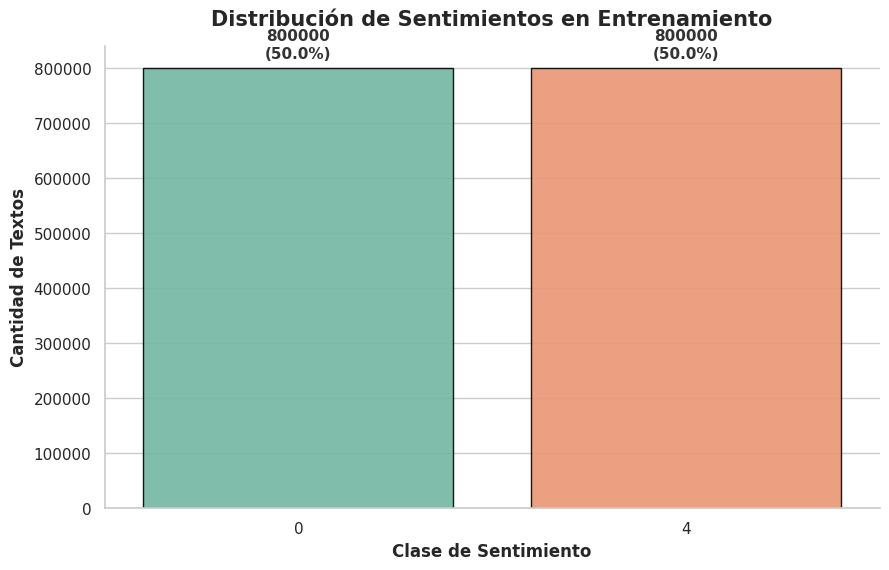

In [10]:
# Configuración de estilo más limpio y profesional
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Crear el gráfico con bordes y mejor paleta
ax = sns.countplot(data=df_train, x='target', palette='Set2', edgecolor='black', alpha=0.9)

# Añadir etiquetas de datos (cantidad y porcentaje) sobre cada barra
total = len(df_train)
for p in ax.patches:
    height = p.get_height()
    porcentaje = f'{100 * height / total:.1f}%'
    # Colocar el texto
    ax.annotate(f'{int(height)}\n({porcentaje})',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                color='#333333', xytext=(0, 5), textcoords='offset points')

# Detalles estéticos finales
plt.title('Distribución de Sentimientos en Entrenamiento', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Clase de Sentimiento', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Textos', fontsize=12, fontweight='bold')
sns.despine() # Elimina los bordes superior y derecho para mayor limpieza visual
plt.show()

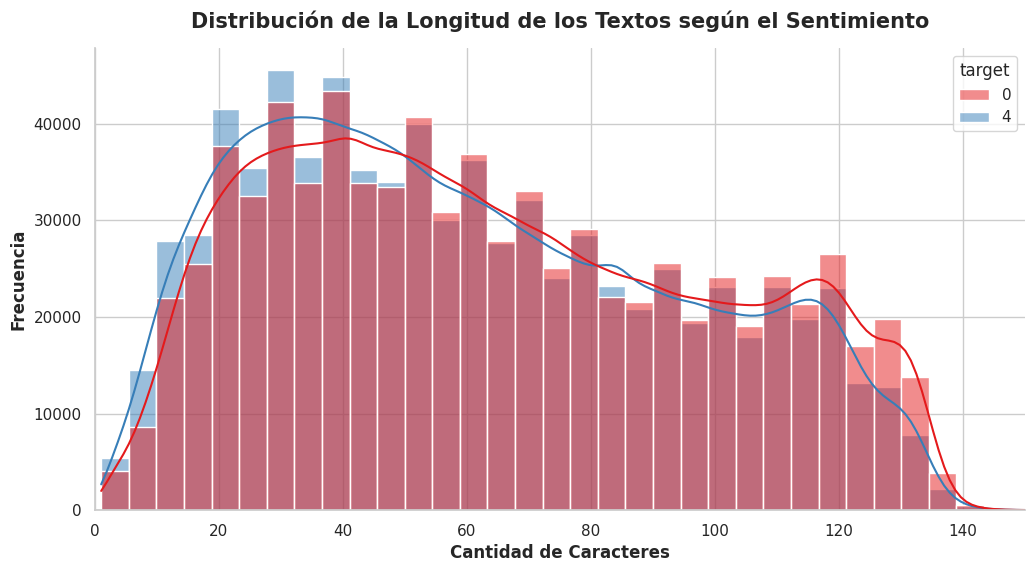

In [11]:
# 1. Calculamos la longitud de cada texto limpio temporalmente
df_train['longitud_texto'] = df_train['text_limpio'].astype(str).apply(len)

# 2. Generamos un gráfico de distribución (Histograma + Curva de Densidad)
plt.figure(figsize=(12, 6))
sns.histplot(data=df_train, x='longitud_texto', hue='target', kde=True,
             palette='Set1', alpha=0.5, bins=40)

# Detalles estéticos
plt.title('Distribución de la Longitud de los Textos según el Sentimiento', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Cantidad de Caracteres', fontsize=12, fontweight='bold')
plt.ylabel('Frecuencia', fontsize=12, fontweight='bold')
plt.xlim(0, 150) # Ajusta este valor si tus textos son más largos
sns.despine()
plt.show()

# 3. Borramos la columna temporal para mantener el dataset limpio
df_train.drop(columns=['longitud_texto'], inplace=True)

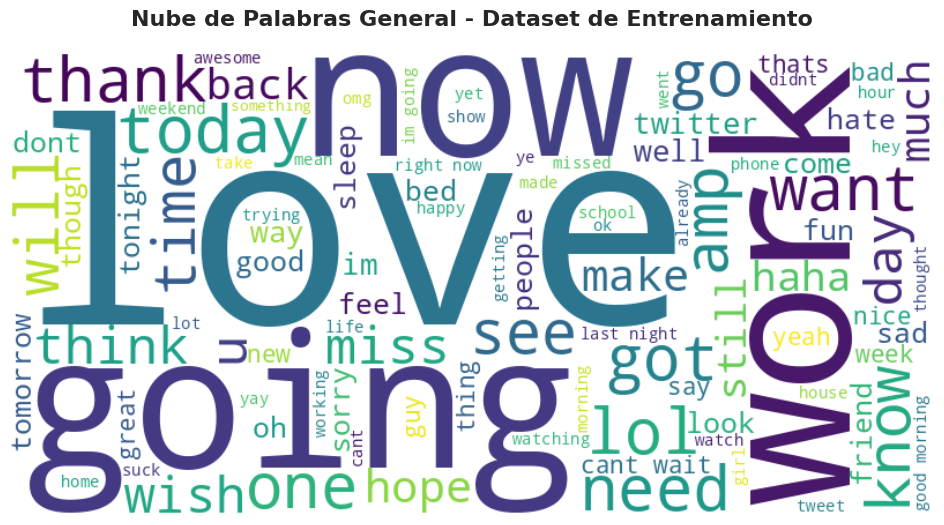

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Unimos todos los textos limpios en un solo string gigante
texto_completo = ' '.join(df_train['text_limpio'].astype(str))

# 2. Configuramos y generamos la nube de palabras
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='viridis',
                      max_words=100, # Límite de palabras a mostrar
                      contour_width=1,
                      contour_color='steelblue').generate(texto_completo)

# 3. Dibujamos el gráfico
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Nube de Palabras General - Dataset de Entrenamiento', fontsize=16, fontweight='bold', pad=20)
plt.axis('off') # Apagamos los ejes porque no aportan en este gráfico
plt.show()

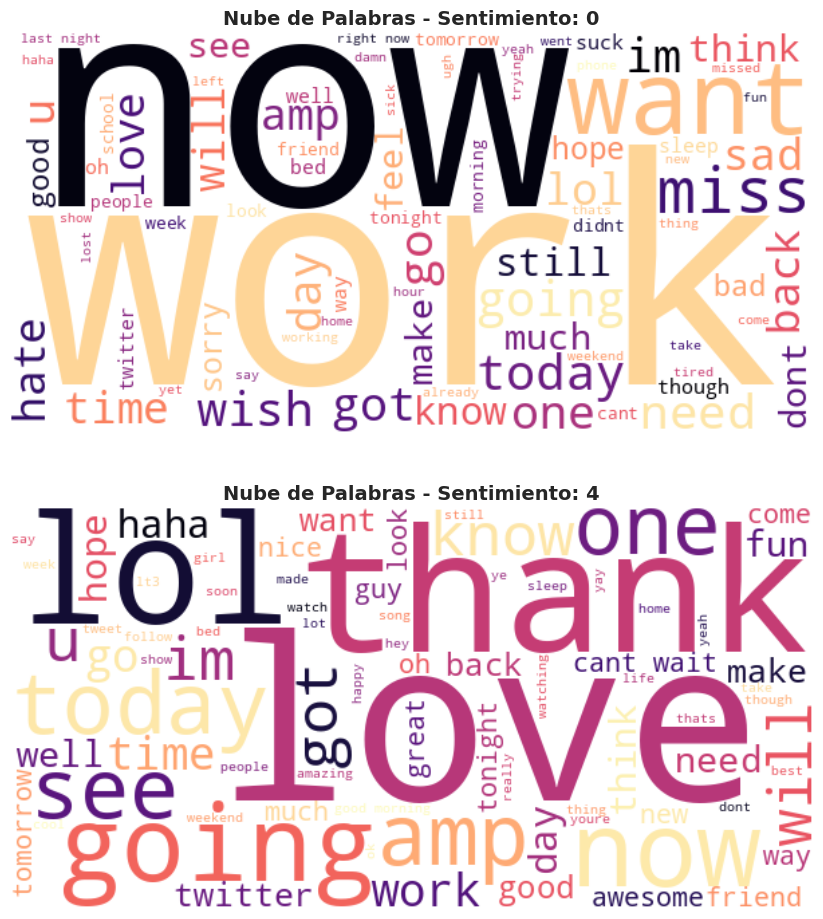

In [13]:
# Obtenemos los sentimientos únicos en el target
sentimientos = df_train['target'].unique()

# Configuramos el tamaño de la figura principal dependiendo de la cantidad de clases
plt.figure(figsize=(15, 5 * len(sentimientos)))

# Iteramos sobre cada sentimiento para crear su propia nube
for i, sentimiento in enumerate(sentimientos, 1):
    # Filtramos el texto solo para este sentimiento
    textos_clase = df_train[df_train['target'] == sentimiento]['text_limpio']
    texto_unido = ' '.join(textos_clase.astype(str))

    # Generamos la nube
    wc = WordCloud(width=600, height=300,
                   background_color='white',
                   colormap='magma',
                   max_words=80).generate(texto_unido)

    # Creamos un subplot para cada sentimiento
    plt.subplot(len(sentimientos), 1, i)
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'Nube de Palabras - Sentimiento: {sentimiento}', fontsize=14, fontweight='bold')
    plt.axis('off')

plt.tight_layout(pad=3.0)
plt.show()

En este EDA se encontro que ambos tipos de tweet se encuentran equilibrados (0 y4), tambien, que la longitud de los textos no es una variable que aporte a el aprendizaje.

Pero, al revisar los wordcloud, se observa una diferencia en el lexico entre los tweets positivos y negativos, lo que beneficiara el aprendizaje guiado por este ultimo factor.